In [20]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, List
import random

In [21]:
class AgentState(TypedDict):
    player_name: str
    guesses: List[int]
    attempts: int
    lower_bound: int
    upper_bound: int
    secret_number: int
    count: int

In [22]:
def setup_node(state: AgentState) -> AgentState:
    state['lower_bound'] = 1
    state['upper_bound'] = 20
    state['attempts'] = 7
    state['count'] = 0
    state['guesses'] = []

    print(f"Hello, {state['player_name']}!")

    return state

def guess_node(state: AgentState) -> AgentState:
    state['guesses'].append(random.randint(state['lower_bound'], state['upper_bound']))
    print(f"the {state['count']} guess is {state['guesses'][state['count']]}")

    state['count'] += 1
    
    return state

def hint_node(state: AgentState) -> AgentState:
    if state['guesses'][state['count'] - 1] == state['secret_number']:
        print("You won the game")

        return "over"
    
    elif state['count'] - 1 >= state['attempts']:
        print("You lost the game")

        return "over"
    
    elif state['guesses'][state['count'] - 1] >= state['secret_number']:
        state['upper_bound'] = state['guesses'][state['count'] - 1]
        print(f"The {state['count'] - 1} guess was greater than a secret (up_bound: {state['upper_bound']}, low_bound: {state['lower_bound']})")
        return "repeat"
  
    elif state['guesses'][state['count'] - 1] <= state['secret_number']:
        state['lower_bound'] = state['guesses'][state['count'] - 1]
        print(f"The {state['count'] - 1} guess was less than a secret")
        return "repeat"


In [23]:
graph = StateGraph(AgentState)

graph.add_node("setup_node", setup_node)
graph.add_node("guess_node", guess_node)

graph.add_edge(START, "setup_node")
graph.add_edge("setup_node", "guess_node")
graph.add_conditional_edges(
    "guess_node",
    hint_node,

    {
        "repeat": "guess_node",
        "over": END
    }
)

In [24]:
app = graph.compile()

In [27]:
result = app.invoke({"player_name": "Alex", "secret_number": 7})

Hello, Alex!
the 0 guess is 15
The 0 guess was greater than a secret (up_bound: 15, low_bound: 1)
the 1 guess is 5
The 1 guess was less than a secret
the 2 guess is 14
The 2 guess was greater than a secret (up_bound: 14, low_bound: 1)
the 3 guess is 7
You won the game


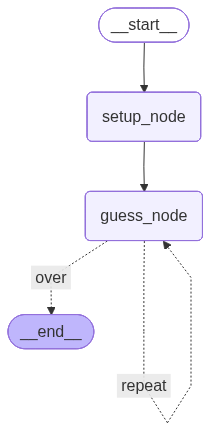

In [28]:
#drawing a graph just to look at it
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))